In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/raw/RawData.csv", sep=";")
df.head()

# Dimensiones
print(df.shape)

# Primeras filas
df.head()

# Tipos de datos y valores no nulos
df.info()


(424, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 424 entries, 0 to 423
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       424 non-null    object 
 1   Edad             417 non-null    float64
 2   Sexo             417 non-null    float64
 3   Fumador          417 non-null    float64
 4   Dislipemia       417 non-null    float64
 5   Diabetes         417 non-null    float64
 6   HTA              417 non-null    float64
 7   IAM              417 non-null    float64
 8   ERC              393 non-null    float64
 9   EPOC             393 non-null    float64
 10  ACV              417 non-null    float64
 11  FA               393 non-null    float64
 12  CANCER           393 non-null    float64
 13  ICC              393 non-null    float64
 14  EAP              393 non-null    float64
 15  Diam AAA pre IQ  105 non-null    float64
 16  TTO              422 non-null    float64
 17  FORMA 

In [4]:
# Vamos a ver cuántas filas reciben el tratamiento 0, cuántas el 1 y cuántas el 2.
df['TTO'] = pd.to_numeric(df['TTO'], errors='coerce')

conteo = df['TTO'].value_counts(dropna=False).sort_index()

print("Conteo de filas por Tipo de Tratamiento (0, 1, 2):")
print(conteo)

# Lo vemos más o menos uniforme, con 40 muestras menos en el tipo de tratamiento 1
# Sin embargo vemos que esta tratando cada tipo como floats, y eso no lo queremos

Conteo de filas por Tipo de Tratamiento (0, 1, 2):
TTO
0.0    154
1.0    112
2.0    156
NaN      2
Name: count, dtype: int64


In [5]:
# Vamos a ver cada columna y el tipo de variable que tiene
# print(df.info())

# Datos faltantes o nulos

# Vamos a ver las columnas con mas de un 40% de datos nulos
columnas_faltanes = df.isnull().mean()
columnas_50 = columnas_faltanes[columnas_faltanes > 0.4]
print(columnas_50)

# Vamos a sacar Diam AAA pre IQ porque faltan el 75% de los datos
columnas_a_eliminar = columnas_50.index.tolist()
df.drop(labels=columnas_a_eliminar, axis=1, inplace=True)

# Todo está a float. Cambiaremos cada una a su tipo correspondiente
df["Edad"] = df["Edad"].astype('Int64')
df["Sexo"] = df["Sexo"].astype(bool)
df["Fumador"] = df["Fumador"].astype('Int64').astype("category")
df["Dislipemia"] = df["Dislipemia"].astype(bool)
df["Diabetes"] = df["Diabetes"].astype(bool)
df["HTA"] = df["HTA"].astype(bool)
df["IAM"] = df["IAM"].astype(bool)
df["ERC"] = df["ERC"].astype(bool)
df["EPOC"] = df["EPOC"].astype(bool)
df["ACV"] = df["ACV"].astype(bool)
df["FA"] = df["FA"].astype(bool)
df["CANCER"] = df["CANCER"].astype(bool)
df["ICC"] = df["ICC"].astype(bool)
df["EAP"] = df["EAP"].astype(bool)
df["TTO"] = df["TTO"].astype('Int64').astype("category")
df["FORMA INTERV"] = df["FORMA INTERV"].astype(bool)

print(df.info())
print(df.head())


Diam AAA pre IQ    0.752358
dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 424 entries, 0 to 423
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Unnamed: 0    424 non-null    object  
 1   Edad          417 non-null    Int64   
 2   Sexo          424 non-null    bool    
 3   Fumador       417 non-null    category
 4   Dislipemia    424 non-null    bool    
 5   Diabetes      424 non-null    bool    
 6   HTA           424 non-null    bool    
 7   IAM           424 non-null    bool    
 8   ERC           424 non-null    bool    
 9   EPOC          424 non-null    bool    
 10  ACV           424 non-null    bool    
 11  FA            424 non-null    bool    
 12  CANCER        424 non-null    bool    
 13  ICC           424 non-null    bool    
 14  EAP           424 non-null    bool    
 15  TTO           422 non-null    category
 16  FORMA INTERV  424 non-null    bool    
dtypes: Int64(1)

In [8]:
# Antes de hacer una matriz de correlación, sacaremos la primer columna que tiene el nombre del hospital y el número de paciente, que no es necesario
df.drop(columns=[df.columns[0]], inplace=True)
print(df.head())

    Sexo Fumador  Dislipemia  Diabetes    HTA    IAM    ERC   EPOC    ACV  \
0  False       1        True     False  False  False  False   True  False   
1  False       0       False     False  False  False  False   True  False   
2  False       0        True     False  False  False  False   True  False   
3  False       0        True     False   True  False  False  False  False   
4  False       0        True     False  False  False  False  False  False   

      FA  CANCER    ICC    EAP TTO  FORMA INTERV  
0  False    True  False  False   0          True  
1  False   False  False  False   2         False  
2  False   False  False  False   2         False  
3  False    True  False  False   2          True  
4  False   False  False   True   1         False  


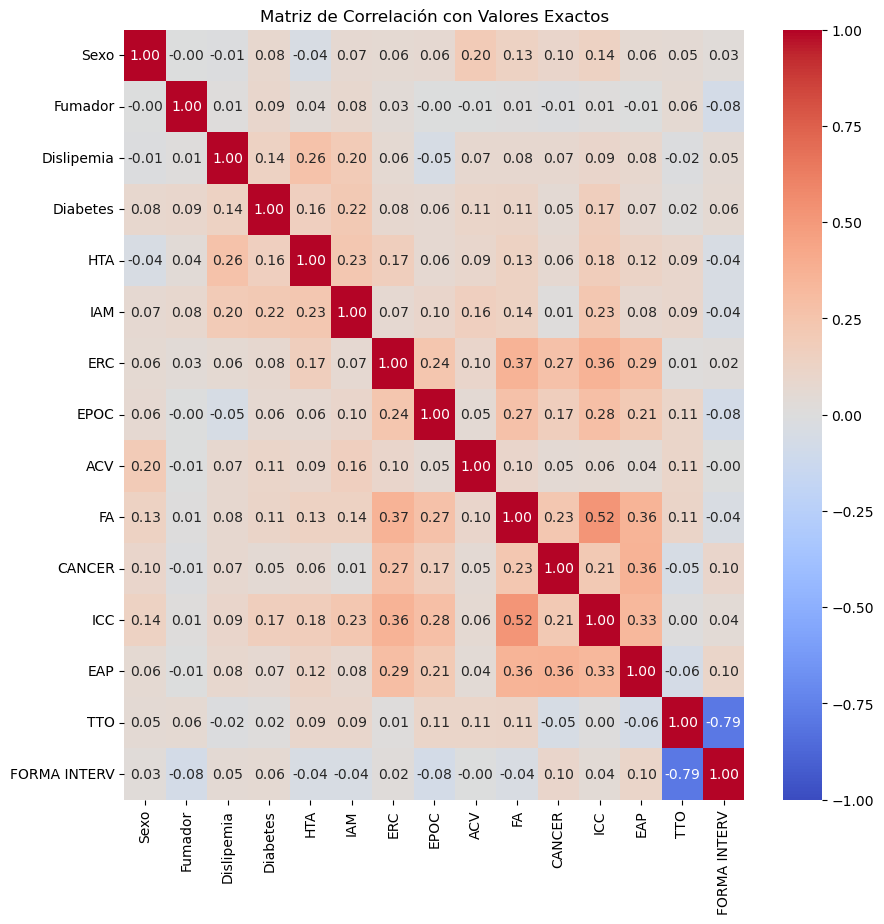

In [15]:
# Vamos a hacer una matriz de correlación para ver variables que se comporten de manera muy similar.
matriz_de_correlacion = df.corr()
plt.figure(figsize=(10, 10))
sns.heatmap(matriz_de_correlacion, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            vmin=-1, 
            vmax=1)

plt.title("Matriz de Correlación con Valores Exactos")
plt.show()